# Healthcare Utilization Personas
## Notebook 1 of 3: EDA & Feature Engineering

**Contributors:** Michaela Donahue, Lily Vyhanek, Zhiwei (Rachel) Huang  
**Data:** `Data/`  
**Scope:** Feature construction (obs window 2019-2020), target labeling (2021), EDA.  
**Caveat:** Synthea is synthetic data -- this is a pipeline demonstration, not real clinical findings.

---

## 0. Imports & Config

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Update this path if you move the Data folder
DATA_PATH = "Data"
print("Files found:", sorted(os.listdir(DATA_PATH)))

Files found: ['allergies.csv', 'careplans.csv', 'claims.csv', 'claims_transactions.csv', 'conditions.csv', 'devices.csv', 'encounters.csv', 'imaging_studies.csv', 'immunizations.csv', 'medications.csv', 'observations.csv', 'organizations.csv', 'patients.csv', 'payer_transitions.csv', 'payers.csv', 'procedures.csv', 'profile_df_features.csv', 'profile_df_with_clusters.csv', 'providers.csv', 'supplies.csv']


---
## 1. Load Data

In [20]:
patients_df    = pd.read_csv(os.path.join(DATA_PATH, "patients.csv"))
encounters_df  = pd.read_csv(os.path.join(DATA_PATH, "encounters.csv"))
medications_df = pd.read_csv(os.path.join(DATA_PATH, "medications.csv"))
conditions_df  = pd.read_csv(os.path.join(DATA_PATH, "conditions.csv"))

for name, df in [("patients",patients_df),("encounters",encounters_df),
                 ("medications",medications_df),("conditions",conditions_df)]:
    print(f"  {name:12s}: {len(df):,} rows x {df.shape[1]} cols")

  patients    : 1,163 rows x 25 cols
  encounters  : 61,459 rows x 15 cols
  medications : 56,430 rows x 13 cols
  conditions  : 38,094 rows x 6 cols


---
## 2. Cleaning & Feature Construction

### 2.1 Demographics Baseline

In [21]:
# Parse dates once up front for all four tables
patients_df["BIRTHDATE"]   = pd.to_datetime(patients_df["BIRTHDATE"])
encounters_df["START"]     = pd.to_datetime(encounters_df["START"])
medications_df["START"]    = pd.to_datetime(medications_df["START"])
conditions_df["START"]     = pd.to_datetime(conditions_df["START"])

# Age at end of observation window; year-only matches Synthea conventions
patients_df["AGE_2020"] = 2020 - patients_df["BIRTHDATE"].dt.year

patients_clean = (
    patients_df[["Id","AGE_2020","GENDER","RACE"]]
    .copy()
    .rename(columns={"Id":"PATIENT_ID"})
)
print(f"Cohort: {len(patients_clean):,} patients")
patients_clean.head(3)

Cohort: 1,163 patients


,PATIENT_ID,AGE_2020,GENDER,RACE
0,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,1,M,white
1,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,15,F,white
2,339144f8-50e1-633e-a013-f361391c4cff,22,M,white


### 2.2 Historical Features (Observation Window: 2019-2020)

In [22]:
OBS_YEARS = [2019, 2020]
enc_hist  = encounters_df[encounters_df["START"].dt.year.isin(OBS_YEARS)].copy()
med_hist  = medications_df[medications_df["START"].dt.year.isin(OBS_YEARS)].copy()
cond_hist = conditions_df[conditions_df["START"].dt.year.isin(OBS_YEARS)].copy()

for name, df in [("enc_hist",enc_hist),("med_hist",med_hist),("cond_hist",cond_hist)]:
    print(f"  {name}: {len(df):,} records")

  enc_hist: 6,418 records
  med_hist: 4,723 records
  cond_hist: 3,722 records


In [23]:
# -- Utilization & cost aggregates --
enc_summary_hist = enc_hist.groupby("PATIENT").agg(
    HIST_TOTAL_ENCOUNTERS=("Id","size"),
    HIST_TOTAL_EXPENSES=("TOTAL_CLAIM_COST","sum"),
    HIST_TOTAL_COVERAGE=("PAYER_COVERAGE","sum")
).reset_index()
# Out-of-pocket = total claim minus payer coverage
enc_summary_hist["HIST_TOTAL_OOP"] = (
    enc_summary_hist["HIST_TOTAL_EXPENSES"] - enc_summary_hist["HIST_TOTAL_COVERAGE"]
)

# -- Emergency visit count --
emergency_hist = (
    enc_hist[enc_hist["ENCOUNTERCLASS"] == "emergency"]
    .groupby("PATIENT").size()
    .reset_index(name="HIST_EMERGENCY_VISITS")
)

# -- Medication and condition volume --
med_counts_hist       = med_hist.groupby("PATIENT").size().reset_index(name="HIST_MEDICATION_COUNT")
condition_counts_hist = cond_hist.groupby("PATIENT").size().reset_index(name="HIST_CONDITION_COUNT")
print("Aggregation complete.")

Aggregation complete.


In [24]:
# Binary indicator matrices for top-10 conditions and medications.
# Binarizing (vs. counting) prevents high-frequency patients from dominating clustering.
TOP_N = 10

def make_binary_pivot(df, patient_col, desc_col, top_n, prefix):
    """Patient x item indicator matrix. 1 = had the item at least once in the window."""
    top_items = df[desc_col].value_counts().head(top_n).index
    pivot = (
        df[df[desc_col].isin(top_items)]
        .pivot_table(index=patient_col, columns=desc_col, aggfunc="size", fill_value=0)
    )
    return (pivot > 0).astype(int).add_prefix(prefix)

cond_pivot_hist = make_binary_pivot(cond_hist,"PATIENT","DESCRIPTION",TOP_N,"Hist_Condition_")
med_pivot_hist  = make_binary_pivot(med_hist, "PATIENT","DESCRIPTION",TOP_N,"Hist_Medication_")
print(f"Condition indicators: {cond_pivot_hist.shape[1]}  |  Medication indicators: {med_pivot_hist.shape[1]}")

Condition indicators: 10  |  Medication indicators: 10


In [25]:
### 2.3 Future Target (Prediction Window: 2021)

In [26]:
PRED_YEAR = 2021
enc_2021  = encounters_df[encounters_df["START"].dt.year == PRED_YEAR].copy()

enc_summary_2021 = enc_2021.groupby("PATIENT").agg(
    EXPENSES_2021=("TOTAL_CLAIM_COST","sum"),
    ENCOUNTERS_2021=("Id","size")
).reset_index()
print(f"Patients with 2021 activity: {len(enc_summary_2021):,}")

Patients with 2021 activity: 977


### 2.4 Merge into a Patient-Level Profile

In [27]:
# Reset index on pivot outputs so every join is column-based, not index-based.
# This avoids the fragile mixed right_index/right_on logic in the original code.
profile_df = patients_clean.copy()

for table in [
    enc_summary_hist, emergency_hist, med_counts_hist, condition_counts_hist,
    enc_summary_2021,
    cond_pivot_hist.reset_index(),   # PATIENT was the index
    med_pivot_hist.reset_index(),    # PATIENT was the index
]:
    profile_df = profile_df.merge(table, left_on="PATIENT_ID", right_on="PATIENT", how="left")
    profile_df.drop(columns=["PATIENT"], errors="ignore", inplace=True)

print(f"Profile shape: {profile_df.shape}")

Profile shape: (1163, 33)


In [28]:
# Patients absent from a table during the window had zero activity -- fill with 0
hist_fill   = ["HIST_TOTAL_ENCOUNTERS","HIST_TOTAL_EXPENSES","HIST_TOTAL_COVERAGE",
               "HIST_TOTAL_OOP","HIST_EMERGENCY_VISITS","HIST_MEDICATION_COUNT","HIST_CONDITION_COUNT"]
future_fill = ["EXPENSES_2021","ENCOUNTERS_2021"]
clin_cols   = [c for c in profile_df.columns
               if c.startswith("Hist_Condition_") or c.startswith("Hist_Medication_")]

profile_df[hist_fill]   = profile_df[hist_fill].fillna(0)
profile_df[future_fill] = profile_df[future_fill].fillna(0)
profile_df[clin_cols]   = profile_df[clin_cols].fillna(0).astype(int)

nulls = profile_df.isnull().sum()
print("Remaining nulls:", nulls[nulls>0].to_dict() or "None")

Remaining nulls: None


### 2.5 Derived Features & Shared Helpers

In [29]:
# -- High-cost binary target --
# 80th percentile is a standard care-management threshold; adjust as needed
high_cost_threshold = profile_df["EXPENSES_2021"].quantile(0.80)
profile_df["IS_HIGH_COST_2021"] = (profile_df["EXPENSES_2021"] >= high_cost_threshold).astype(int)
print(f"High-cost threshold: ${high_cost_threshold:,.2f}  |  "
      f"High-cost count: {profile_df['IS_HIGH_COST_2021'].sum()} "
      f"({profile_df['IS_HIGH_COST_2021'].mean():.1%})")

# -- Historical utilization tier --
# rank(method='first') breaks ties deterministically before qcut
profile_df["HIST_UTILIZATION_TIER"] = pd.qcut(
    profile_df["HIST_TOTAL_ENCOUNTERS"].rank(method="first"),
    q=3, labels=["Low Utilizer","Mid Utilizer","High Utilizer"]
)

# -- Age group bins (reused in 3.1 and 3.2) --
AGE_BINS   = [0, 18, 35, 50, 65, 100]
AGE_LABELS = ["<18","18-34","35-49","50-64","65+"]
profile_df["Age_Group"] = pd.cut(profile_df["AGE_2020"], bins=AGE_BINS, labels=AGE_LABELS)

# -- SDOH keyword list (reused in 3.4 and 3.5) --
SDOH_KEYWORDS = ["employment","stress","isolation","contact","labor","violence"]

# -- Coverage tier helper (reused in 3.3 and 3.5 -- defined once to stay consistent) --
TIER_ORDER  = ["No Prior Activity","Fully OOP (0%)","Low (1-49%)","Moderate (50-84%)","High (>=85%)"]
TIER_COLORS = ["#5B9BD5","#ED7D31","#A9D18E","#FFC000","#70AD47"]

def compute_coverage_tier(df):
    """Returns a copy of df with HIST_COVERAGE_RATE and COVERAGE_TIER added."""
    df = df.copy()
    df["HIST_COVERAGE_RATE"] = np.where(
        df["HIST_TOTAL_EXPENSES"] > 0,
        (df["HIST_TOTAL_COVERAGE"] / df["HIST_TOTAL_EXPENSES"]).clip(upper=1.0),
        np.nan
    )
    def _tier(row):
        r = row["HIST_COVERAGE_RATE"]
        if pd.isna(r):  return "No Prior Activity"
        if r == 0:      return "Fully OOP (0%)"
        if r < 0.5:     return "Low (1-49%)"
        if r < 0.85:    return "Moderate (50-84%)"
        return "High (>=85%)"
    df["COVERAGE_TIER"] = df.apply(_tier, axis=1)
    return df

print("Helpers ready.")

High-cost threshold: $9,892.67  |  High-cost count: 233 (20.0%)
Helpers ready.


---
## 3. Exploratory Data Analysis

### 3.1 Cohort Age Distribution

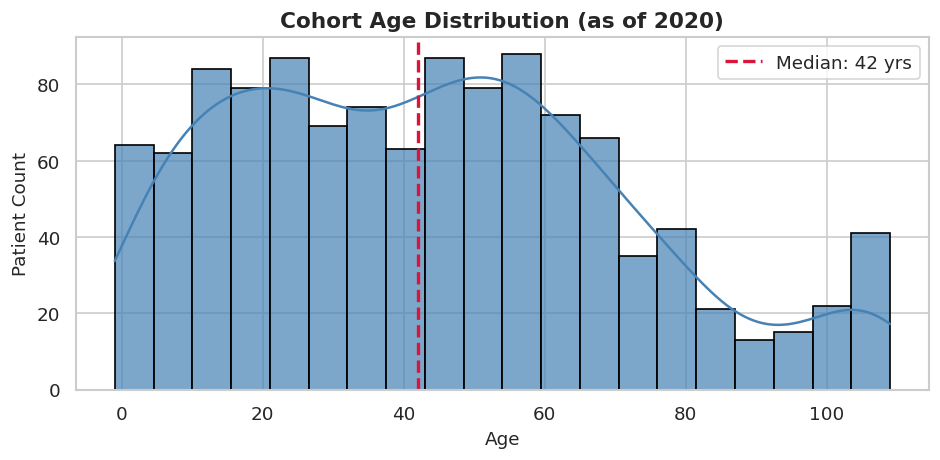

Age_Group
<18      229
18-34    236
35-49    212
50-64    218
65+      183


In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=profile_df, x="AGE_2020", bins=20, kde=True,
             color="steelblue", edgecolor="black", alpha=0.7, ax=ax)
median_age = profile_df["AGE_2020"].median()
ax.axvline(median_age, color="crimson", linestyle="--", linewidth=2, label=f"Median: {median_age:.0f} yrs")
ax.set_title("Cohort Age Distribution (as of 2020)", fontsize=13, fontweight="bold")
ax.set_xlabel("Age", fontsize=11)
ax.set_ylabel("Patient Count", fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()
print(profile_df["Age_Group"].value_counts().sort_index().to_string())

**Finding:** Median age 42; broadly bimodal (peaks ~10-30 and ~50-60). Flat working-age distribution is favorable for generalizability.

### 3.2 Average Healthcare Expenses by Age Group and Gender

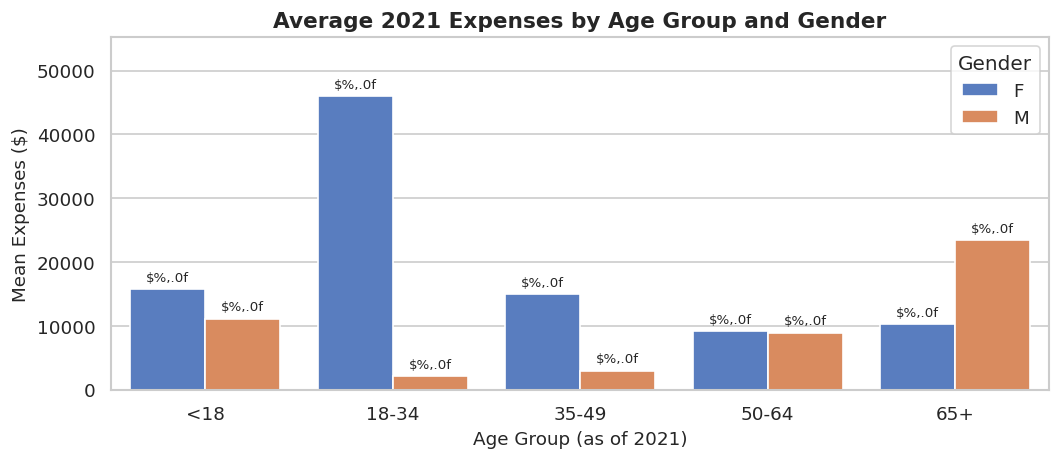

In [31]:
# Use age as of 2021 since we are comparing against 2021 expenses;
# restrict to patients who were actually active that year
df_32 = profile_df[profile_df["ENCOUNTERS_2021"] > 0].copy()
df_32["AGE_2021"]  = df_32["AGE_2020"] + 1
df_32["Age_Group"] = pd.cut(df_32["AGE_2021"], bins=AGE_BINS, labels=AGE_LABELS)

expense_summary = (
    df_32.groupby(["Age_Group","GENDER"], observed=True)["EXPENSES_2021"]
    .mean().reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=expense_summary, x="Age_Group", y="EXPENSES_2021",
            hue="GENDER", palette="muted", ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="$%,.0f", padding=3, fontsize=8)
ax.set_title("Average 2021 Expenses by Age Group and Gender", fontsize=13, fontweight="bold")
ax.set_xlabel("Age Group (as of 2021)", fontsize=11)
ax.set_ylabel("Mean Expenses ($)", fontsize=11)
ax.set_ylim(0, expense_summary["EXPENSES_2021"].max() * 1.2)
ax.legend(title="Gender")
plt.tight_layout()
plt.show()

**Finding:** Females 18-34 are dramatically more expensive than same-age males (maternity-driven). Gender gap narrows through middle age and reverses at 65+. The age-gender interaction is a strong candidate feature for the supervised model.

### 3.3 Coverage Gap Paradox: Historical Coverage Rate vs. Future Cost Risk

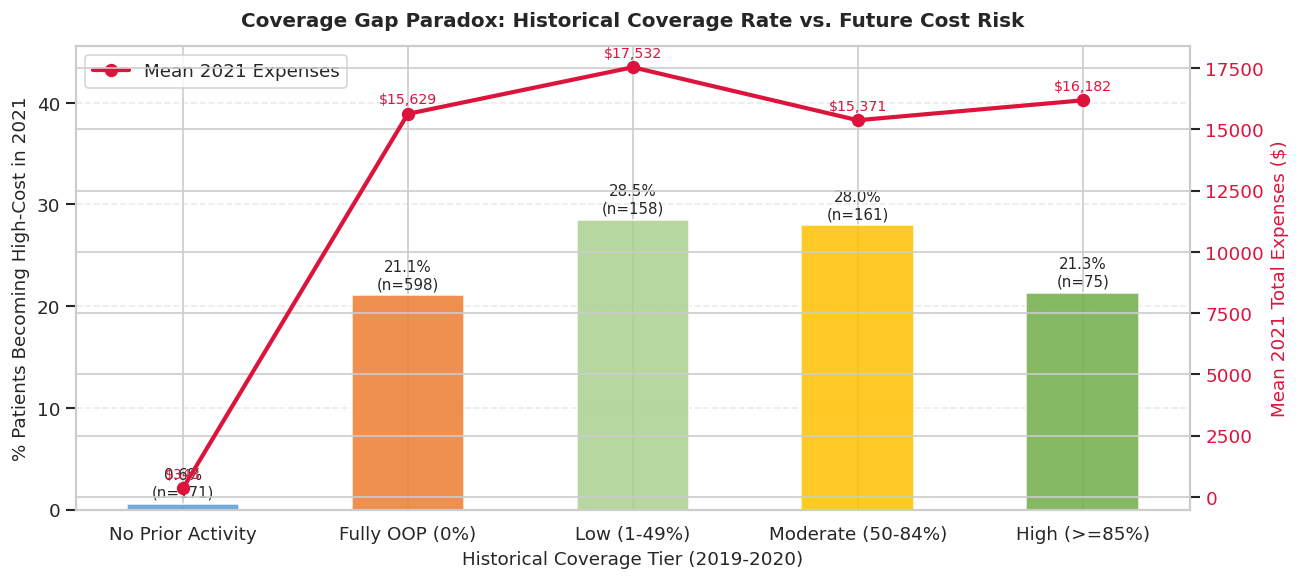

In [32]:
df_33 = compute_coverage_tier(profile_df)

summary_33 = (
    df_33.groupby("COVERAGE_TIER", observed=True)
    .agg(N=("PATIENT_ID","size"),
         HIGH_COST_RATE=("IS_HIGH_COST_2021","mean"),
         MEAN_EXPENSES_2021=("EXPENSES_2021","mean"))
    .reindex(TIER_ORDER).reset_index()
)

fig, ax1 = plt.subplots(figsize=(11, 5))
bars = ax1.bar(summary_33["COVERAGE_TIER"], summary_33["HIGH_COST_RATE"]*100,
               color=TIER_COLORS, alpha=0.85, width=0.5, zorder=2)
for bar, rate, n in zip(bars, summary_33["HIGH_COST_RATE"], summary_33["N"]):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
             f"{rate*100:.1f}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax1.set_ylabel("% Patients Becoming High-Cost in 2021", fontsize=11)
ax1.set_ylim(0, summary_33["HIGH_COST_RATE"].max()*160)
ax1.set_xlabel("Historical Coverage Tier (2019-2020)", fontsize=11)
ax1.grid(axis="y", linestyle="--", alpha=0.4, zorder=1)

ax2 = ax1.twinx()
ax2.plot(summary_33["COVERAGE_TIER"], summary_33["MEAN_EXPENSES_2021"],
         color="crimson", marker="o", linewidth=2.5, markersize=7, label="Mean 2021 Expenses", zorder=3)
for i, val in enumerate(summary_33["MEAN_EXPENSES_2021"]):
    ax2.text(i, val+300, f"${val:,.0f}", ha="center", va="bottom", fontsize=8.5, color="crimson")
ax2.set_ylabel("Mean 2021 Total Expenses ($)", fontsize=11, color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")

plt.title("Coverage Gap Paradox: Historical Coverage Rate vs. Future Cost Risk",
          fontsize=12, fontweight="bold", pad=12)
lines, labels = ax2.get_legend_handles_labels()
ax1.legend(lines, labels, loc="upper left")
plt.tight_layout()
plt.show()

**Finding:** Partially covered patients (Low 1-49%) show higher risk than the fully uninsured -- the uninsured tend to avoid expensive care. Coverage rate is non-monotonic; treat it as a continuous feature rather than assuming linearity.

### 3.4 SDOH vs. Clinical Conditions: Which Historical Diagnoses Best Predict Future High Cost?

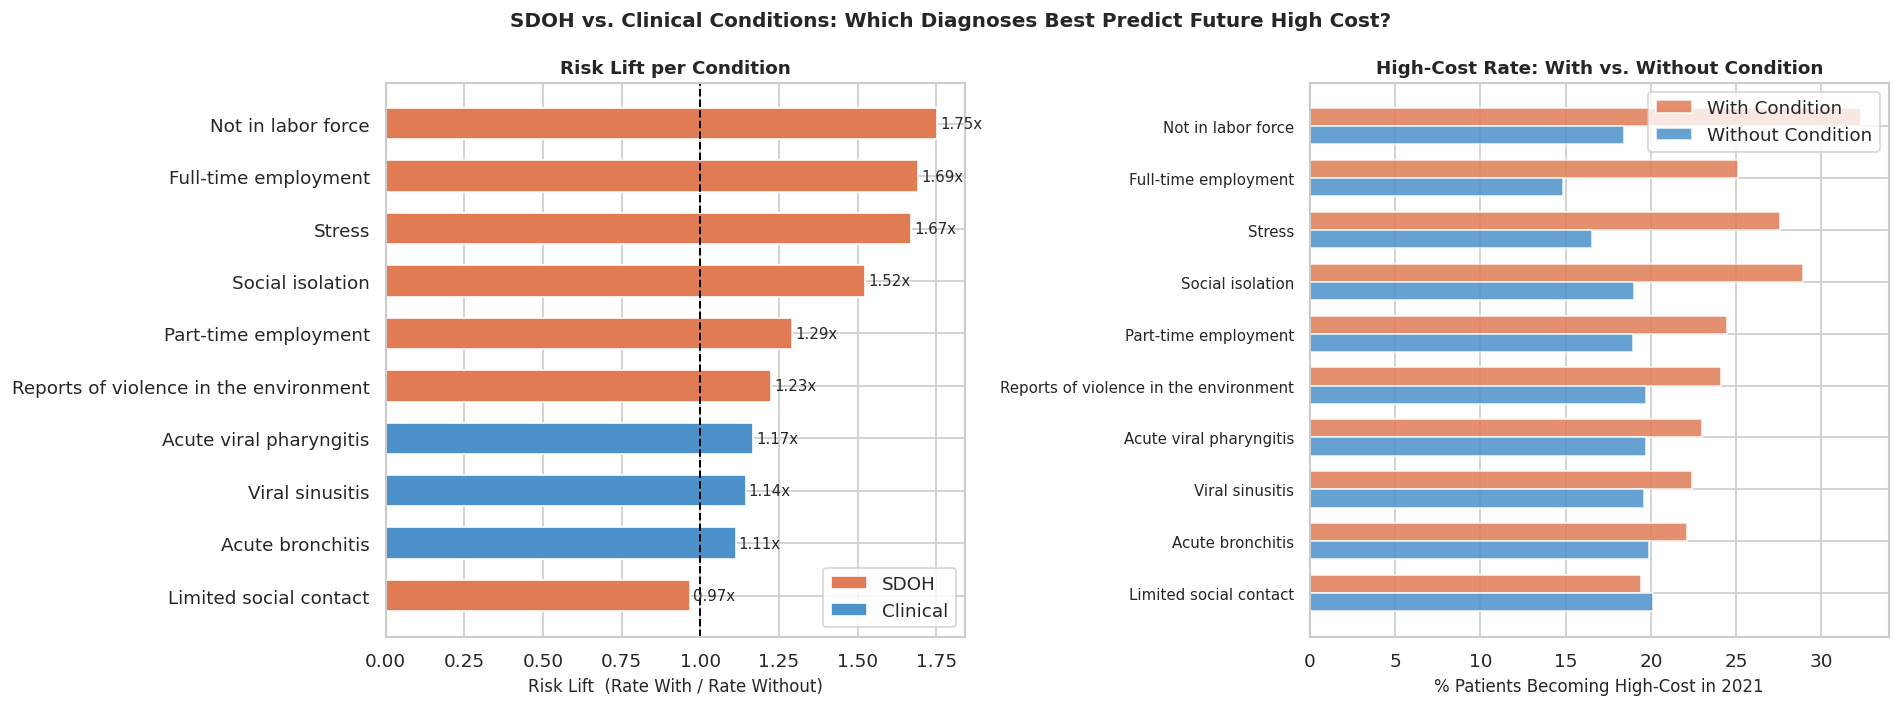

In [33]:
cond_cols   = [c for c in profile_df.columns if c.startswith("Hist_Condition_")]
cond_labels = (
    pd.Series(cond_cols)
    .str.replace("Hist_Condition_","",regex=False)
    .str.replace(" (finding)","",regex=False)
    .str.replace(" (disorder)","",regex=False)
    .tolist()
)

# Risk lift = high-cost rate WITH condition / rate WITHOUT condition
records = []
for col, label in zip(cond_cols, cond_labels):
    has   = profile_df[profile_df[col] == 1]
    hasnt = profile_df[profile_df[col] == 0]
    r_with    = has["IS_HIGH_COST_2021"].mean()
    r_without = hasnt["IS_HIGH_COST_2021"].mean()
    records.append({"Condition":label,"N_With":len(has),
                    "Rate_With":r_with,"Rate_Without":r_without,
                    "Risk_Lift":r_with/r_without if r_without>0 else np.nan})

df_34 = pd.DataFrame(records).sort_values("Risk_Lift",ascending=True).reset_index(drop=True)
df_34["Type"] = df_34["Condition"].apply(
    lambda x: "SDOH" if any(k in x.lower() for k in SDOH_KEYWORDS) else "Clinical"
)
bar_colors = df_34["Type"].map({"SDOH":"#E07B54","Clinical":"#4C91C9"})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].barh(df_34["Condition"], df_34["Risk_Lift"], color=bar_colors, edgecolor="white", height=0.6)
axes[0].axvline(1.0, color="black", linestyle="--", linewidth=1.2)
for bar, val in zip(bars, df_34["Risk_Lift"]):
    axes[0].text(val+0.01, bar.get_y()+bar.get_height()/2, f"{val:.2f}x", va="center", fontsize=9)
axes[0].set_xlabel("Risk Lift  (Rate With / Rate Without)", fontsize=10)
axes[0].set_title("Risk Lift per Condition", fontsize=11, fontweight="bold")
axes[0].legend(handles=[Patch(facecolor="#E07B54",label="SDOH"),
                         Patch(facecolor="#4C91C9",label="Clinical")],loc="lower right")

x=np.arange(len(df_34)); w=0.35
axes[1].barh(x+w/2, df_34["Rate_With"]*100,   w, label="With Condition",    color="#E07B54", alpha=0.85)
axes[1].barh(x-w/2, df_34["Rate_Without"]*100, w, label="Without Condition", color="#4C91C9", alpha=0.85)
axes[1].set_yticks(x)
axes[1].set_yticklabels(df_34["Condition"],fontsize=9)
axes[1].set_xlabel("% Patients Becoming High-Cost in 2021",fontsize=10)
axes[1].set_title("High-Cost Rate: With vs. Without Condition",fontsize=11,fontweight="bold")
axes[1].legend()

plt.suptitle("SDOH vs. Clinical Conditions: Which Diagnoses Best Predict Future High Cost?",
             fontsize=12,fontweight="bold")
plt.tight_layout()
plt.show()

**Finding:** All top risk-lift conditions are SDOH; the clinical conditions (bronchitis, sinusitis, pharyngitis) have near-baseline lift. "Not in labor force" leads at ~1.75x. Both employment extremes elevate risk, suggesting a U-shaped relationship.

### 3.5 Compound Risk: Does SDOH Burden Amplify the Coverage Gap Effect?

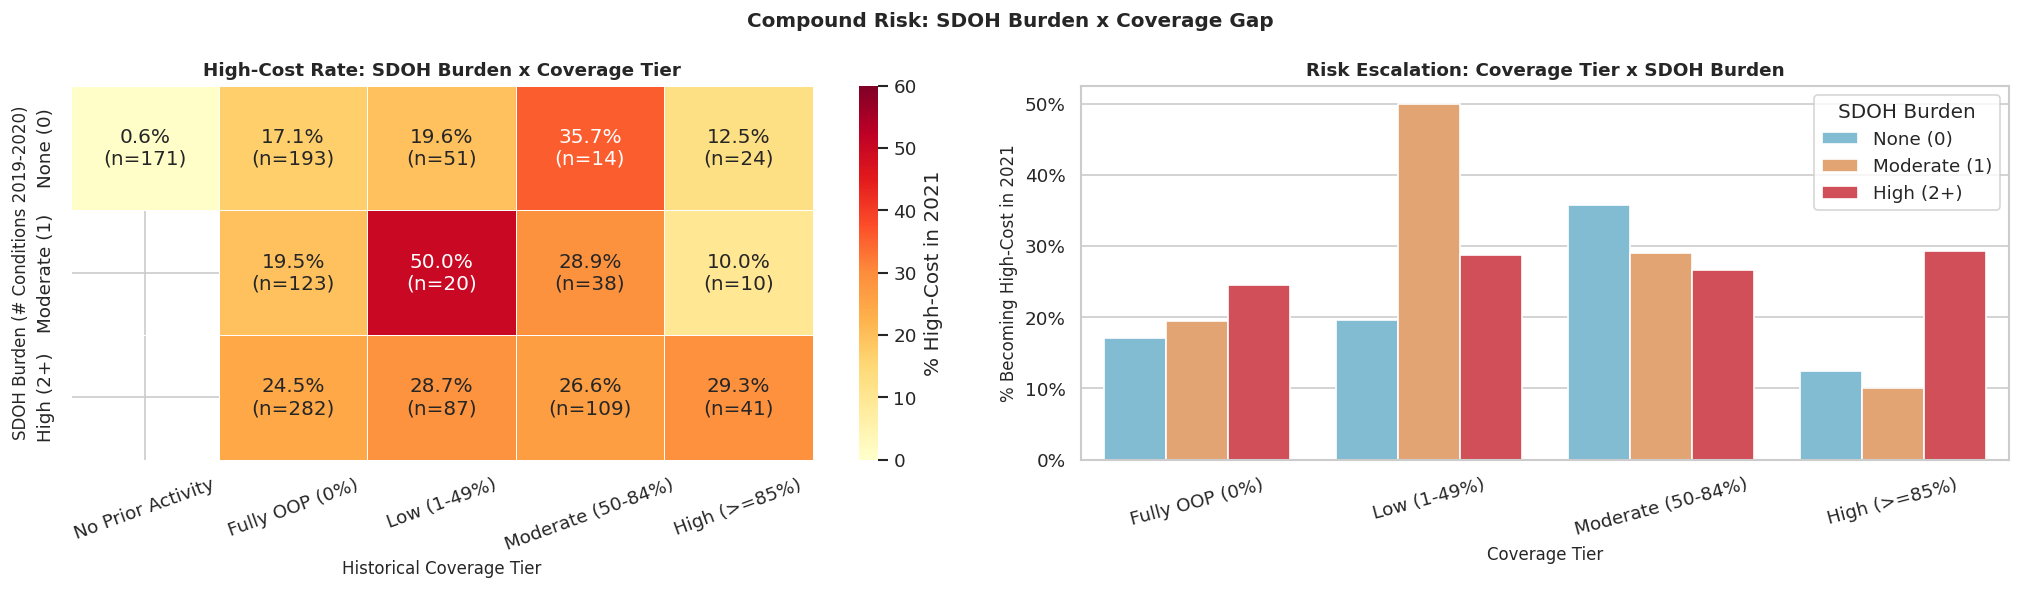

In [34]:
df_35 = compute_coverage_tier(profile_df)

sdoh_cols = [c for c in df_35.columns
             if c.startswith("Hist_Condition_") and any(k in c.lower() for k in SDOH_KEYWORDS)]
df_35["SDOH_COUNT"]  = df_35[sdoh_cols].sum(axis=1)
df_35["SDOH_BURDEN"] = pd.cut(df_35["SDOH_COUNT"], bins=[-1,0,1,10],
                               labels=["None (0)","Moderate (1)","High (2+)"])
SDOH_ORDER = ["None (0)","Moderate (1)","High (2+)"]

heatmap_data = (
    df_35.groupby(["SDOH_BURDEN","COVERAGE_TIER"],observed=True)["IS_HIGH_COST_2021"]
    .mean().unstack().reindex(index=SDOH_ORDER, columns=TIER_ORDER)
)
count_data = (
    df_35.groupby(["SDOH_BURDEN","COVERAGE_TIER"],observed=True)["IS_HIGH_COST_2021"]
    .count().unstack().reindex(index=SDOH_ORDER, columns=TIER_ORDER)
)

annot = heatmap_data.copy().astype(object)
for r in SDOH_ORDER:
    for c in TIER_ORDER:
        rate,n = heatmap_data.loc[r,c], count_data.loc[r,c]
        annot.loc[r,c] = f"{rate*100:.1f}%\n(n={int(n)})" if pd.notna(rate) and pd.notna(n) else "N/A"

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
sns.heatmap(heatmap_data*100, annot=annot, fmt="", cmap="YlOrRd", linewidths=0.5, ax=axes[0],
            cbar_kws={"label":"% High-Cost in 2021"}, vmin=0, vmax=60)
axes[0].set_title("High-Cost Rate: SDOH Burden x Coverage Tier",fontsize=11,fontweight="bold")
axes[0].set_xlabel("Historical Coverage Tier",fontsize=10)
axes[0].set_ylabel("SDOH Burden (# Conditions 2019-2020)",fontsize=10)
axes[0].tick_params(axis="x",rotation=20)

active = ["Fully OOP (0%)","Low (1-49%)","Moderate (50-84%)","High (>=85%)"]
plot_df = heatmap_data.reset_index().melt(id_vars="SDOH_BURDEN",value_name="HighCostRate",var_name="CoverageTier")
sns.barplot(data=plot_df[plot_df["CoverageTier"].isin(active)],
            x="CoverageTier",y="HighCostRate",hue="SDOH_BURDEN",hue_order=SDOH_ORDER,
            palette=["#74C2E1","#F4A261","#E63946"],order=active,ax=axes[1])
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y*100:.0f}%"))
axes[1].set_title("Risk Escalation: Coverage Tier x SDOH Burden",fontsize=11,fontweight="bold")
axes[1].set_xlabel("Coverage Tier",fontsize=10)
axes[1].set_ylabel("% Becoming High-Cost in 2021",fontsize=10)
axes[1].legend(title="SDOH Burden")
axes[1].tick_params(axis="x",rotation=15)

plt.suptitle("Compound Risk: SDOH Burden x Coverage Gap",fontsize=12,fontweight="bold")
plt.tight_layout()
plt.show()

**Finding:** High SDOH (2+) patients stay elevated regardless of coverage tier -- insurance alone cannot offset heavy social burden. The two factors interact non-linearly; the supervised model should include an interaction term.

---
## 4. Export Feature Table

In [35]:
OUTPUT_PATH = os.path.join(DATA_PATH, "profile_df_features.csv")
profile_df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}  |  Shape: {profile_df.shape}")

Saved: Data/profile_df_features.csv  |  Shape: (1163, 36)


In [36]:
profile_df.head()

,PATIENT_ID,AGE_2020,GENDER,RACE,HIST_TOTAL_ENCOUNTERS,HIST_TOTAL_EXPENSES,HIST_TOTAL_COVERAGE,HIST_TOTAL_OOP,HIST_EMERGENCY_VISITS,HIST_MEDICATION_COUNT,...,Hist_Medication_Hydrochlorothiazide 25 MG Oral Tablet,Hist_Medication_Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray,Hist_Medication_Simvastatin 10 MG Oral Tablet,Hist_Medication_Simvastatin 20 MG Oral Tablet,Hist_Medication_amLODIPine 2.5 MG Oral Tablet,Hist_Medication_insulin human isophane 70 UNT/ML / Regular Insulin Human 30 UNT/ML Injectable Suspension [Humulin],Hist_Medication_lisinopril 10 MG Oral Tablet,IS_HIGH_COST_2021,HIST_UTILIZATION_TIER,Age_Group
0,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,1,M,white,10.0,7281.28,6803.22,478.06,0.0,2.0,...,0,0,0,0,0,0,0,0,High Utilizer,<18
1,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,15,F,white,3.0,2493.87,0.00,2493.87,1.0,1.0,...,0,0,0,0,0,0,0,0,Mid Utilizer,<18
2,339144f8-50e1-633e-a013-f361391c4cff,22,M,white,2.0,1994.22,0.00,1994.22,0.0,6.0,...,1,0,0,0,1,0,1,0,Low Utilizer,18-34
3,d488232e-bf14-4bed-08c0-a82f34b6a197,17,F,white,12.0,178139.01,103636.80,74502.21,1.0,0.0,...,0,0,0,0,0,0,0,1,High Utilizer,<18
4,217f95a3-4e10-bd5d-fb67-0cfb5e8ba075,27,M,black,1.0,786.33,0.00,786.33,0.0,0.0,...,0,0,0,0,0,0,0,0,Low Utilizer,18-34
